In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
data = pd.read_csv('/Users/alvarobolanos/Desktop/tda_project/fix/data/BASE FINAL-Tabla 1.csv')

# 1. Analisis preliminar de variables y condición de datos

In [2]:
data.head()

,n,Fecha encuesta,Edad madre,Nacionalidad,Agrupación nacionalidad,Región,Educación,FN hijo,Período,N° embarazo,...,Código alimentos,¿Consumió pan?,Código pan,mgAF/unidad pan,Código pan/día consumido,mg/d AF total pan,mg/d DFE total pan,Total mg/d AF suple y pan,Total mg/d DFE suple y pan,Consumo suple y pan y pastas (si/no)
0,1,8/8/2023 20:34:16,36,1,1,11,7,2/14/22,2,1,...,4,1,1,0.13,2.0,0.26,0.442,5.260,8.942,1
1,4,8/9/2023 11:13:30,39,1,1,7,5,12/27/22,2,3,...,4,1,4,0.05,1.0,0.05,0.085,0.850,1.445,1
2,5,8/9/2023 11:34:11,40,1,1,7,6,3/21/20,2,2,...,4,1,1,0.13,1.0,0.13,0.221,1.130,1.921,1
3,7,8/9/2023 11:51:14,35,1,1,7,7,4/23/22,2,2,...,4,1,1,0.13,1.0,0.13,0.221,0.987,1.678,1
4,8,8/17/2023 21:01:19,30,1,1,9,7,7/23/18,1,1,...,1,1,9,0.09,2.0,0.18,0.306,0.323,0.549,1


In [3]:
print(data.columns)

Index(['n', 'Fecha encuesta', 'Edad madre', 'Nacionalidad',
       'Agrupación nacionalidad', 'Región', 'Educación', 'FN hijo', 'Período',
       'N° embarazo', 'Sexo hijo', 'PN hijo (g)', 'EG hijo (sem)',
       'KG inicio mamá', 'KG fin mamá', 'Dif peso mamá', 'Estatura mamá',
       'IMC antes', 'IMC después', 'Dif IMC', 'Condición mamá',
       '¿Hijo nace c/problema de salud?', 'Patología RN',
       '¿Consume suplementos y/o multivitamínico de AF en embarazo?',
       '¿Consume SAF?', '¿Consume SAF+OSAF?', 'Código SAF',
       'mgAF/cáp SAF+OSAF', '¿Cuántos días de SAF?', '¿Cuántas cáp SAF?',
       'mgAF/día SAF', '¿Consumió MAF?', '¿Consumió MAF completo?',
       'Código MAF', 'mgAF/cáp MAF', '¿Cuántos días de MAF?',
       '¿Cuántas cáp MAF?', 'mgAF/día MAF 1°T', 'Consumo OSAF 1° toma',
       'Consumo OSAF 2° toma', 'Consumo OSAF completo', 'Código OSAF',
       'mgAF/cáp OSAF', '¿Cuántos días de OSAF?', '¿Cuántas cáp OSAF?',
       'mgAF/día OSAF 1°T', 'mgAF/día SAF+OSAF 2°

## Significado de cada variable y tipo de dato

In [ ]:
descripcion_columnas = {
    'n' : 'Identificador encuestado (numerico)',
    'Fecha Encuesta' : 'Fecha en que se realizó la encuesta (fecha)',
    "Edad madre" : 'Edad de la madre al momento de la encuesta (numerico)',
    "Nacionalidad" : 'Nacionalidad de la madre (nominal 1-7)',
    'Agrupación nacionalidad' : "nominal (1-2)",
    'Región' : "Región de residencia (nominal 1-16)",
    'Educación' : 'Nivel educacional de la madre (nominal 1-7)',
    'FN hijo' : 'Fecha de nacimiento de ultimo hijo (fecha)',
    'Período' : 'no se sabe nominal (1-2)',
    'N° embarazo' : 'numero del ultimo embarazo (numerico)',
    'Sexo hijo' : 'nominal (1-3)',
    'PN hijo (g)' : 'peso de hijo al nacer en gramos (numerico)',
    'EG hijo (sem)' : 'edad gestacional del hijo en semanas (numerico)',
    'KG inicio mamá' : 'peso en kilogramos de la madre al iniciar el embarazo (numerico)',
    'KG fin mamá' : 'peso en kilogramos de la madre al terminar su embarazo (numerico)',
    'Dif peso mamá' : 'Diferencia de peso de madre en kilogramos (numerico)',
    'Estatura mamá' : 'estatura mama en centimetros (numerico)',
    'IMC antes' : 'Indice de masa corporal de la madre antes del embarazo (numerico)',
    'IMC después' : 'Indice de masa corporal de la madre despues del embarazo (numerico)',
    'Dif IMC' : 'diferencia en IMC madre (numerico)',
    'Condición mamá' : 'condiciones a las que pudo estar expuesta la madre antes o durante el embarazo (nominal 1-3)',
    '¿Hijo nace c/problema de salud?' : 'responde si el hijo nacio con algun problema de salud (binario)',
    'Patología RN' : 'si la respuesta anterior fue si especifica la condición (nominal 0-10 con 0=no)',
    '¿Consume suplementos y/o multivitamínico de AF en embarazo?' : 'responde si se consumio algun tipo de suplemento de acido folico o multivitaminico durante el embarazo (binario)',
    '¿Consume SAF?' : 'responde si se consumen suplementos de acido folico (binario)',
    '¿Consume SAF+OSAF?' : 'responde si se consumen sumplementos de acido folico y otros suplementos de acido folico (binario)',
    'Código SAF' : 'especifica que suplemento se consumio (nominal 0-42 con 0 = no consumio)',
    'mgAF/cáp SAF+OSAF' : 'miligramos de acido folico por capsula de suplementos (numerico)',
    '¿Cuántos días de SAF?' : 'responde cuantos dias a la semana se consumio suplemento de acido folico (numerico 1-7)',
    '¿Cuántas cáp SAF?' : 'cantidad de capsulas de suplemento de acido folico consumido al dia (nominal 1-3)',
    'mgAF/día SAF' : 'miligramos de acido folico al dia en suplementos de acido folico (numerico)',
    '¿Consumió MAF?' : 'responde si consumio Multivitamínicos con AF (binario)',
    '¿Consumió MAF completo?' : 'responde si consumio Multivitamínicos con AF  completo (binario)',
    'Código MAF' : 'especifica multivitaminico con acido folico (nominal 0-42 con 0 = no consumio)',
    'mgAF/cáp MAF' : 'miligramos de acido folico por capsula de multivtamincio (numerico)',
    '¿Cuántos días de MAF?' : 'responde cuantos dias a la semana se consumio multivitaminico con acido folico (numerico 1-7)',
    '¿Cuántas cáp MAF?' : 'cantidad de capsulas de multivitaminico consumidas al dia (nominal 1-3)',
    'mgAF/día MAF 1°T' : 'miligramos al dia de acido folico en multivitaminico durante primer tercio (numerico)',
    'Consumo OSAF 1° toma' : 'consumo de otros suplementos de acido folico durante el primer tercio (binario)',
    'Consumo OSAF 2° toma' : 'consumo de otros suplementos de acido folico durante el segundo tercio (binario)',
    'Consumo OSAF completo' : 'consumo de otros suplementos de acido folico durante el periodo completo (binario)',
    'Código OSAF' : 'especifica tipo de otro suplemento con acido folico (nominal 0-42 con 0 = no consumio)',
    'mgAF/cáp OSAF' : 'miligramos por capsula de folico en capsula de OSAF (numerico)',
    '¿Cuántos días de OSAF?' : 'responde cuantos dias a la semana se consumio OSAF (numerico 1-7)',
    '¿Cuántas cáp OSAF?' : 'cantidad de capsulas de OSAF consumidas al dia (nominal 1-3)',
    'mgAF/día OSAF 1°T' : 'miligramos al dia de acido folico en OSAF durante primer tercio (numerico)',
    'mgAF/día SAF+OSAF 2°T' : 'miligramos al dia de acido folico en OSAF durante segundo tercio (numerico)',
    'mgAF/día Suplementos y multivitamínico 1°T' : 'miligramos al dia de acido folico en suplementos y multivitaminicos durante primer tercio (numerico)',
    'mg/día DFE suplementos y multivitamínico 1°T' : 'no se sabe (numerico)',
    'Período consumo SAF+OSAF' : 'periodo del embarazo en el que se consumieron suplementos de acido folico (nominal 1-3)',
    'Días consumo MAF' : 'total dias que se consumio multivitaminico de acido folico (numerico)',
    'mgAF/día período MAF' : 'miligramos de acido folico en multivitaminico consumidos por dia (numerico)',
    'Días consumo suplementosAF' : 'total dias que se consumio suplemento de acido folico (numerico)',
    'mgAF/día total período SAF+OSAF' : 'miligramos de acido folico en suplemento consumidos por dia (numerico)',
    'TOTAL AF mg suplementos y multivitamínicos período ' : 'total de acido folico consumido en suplementos y multivitaminicos (numerico)',
    'Código consumo SIN' : 'especifica suplementos sin acido folico (nominal 0-42)',
    'Código alimentos' : 'especifica alimentos dejados de consumir durante el embarazo (nominal 1-4)',
    '¿Consumió pan?' : 'consumio pan a base de trigo durante el embarazo (binario)',
    'Código pan' : 'especifica el pan consumido (nominal 0-15)',
    'mgAF/unidad pan' : 'miligramos de acido folico por unidad de pan (numerico)',
    'Código pan/día consumido' : 'cantidad de pan consumida por dia (nominal 0.5, 0-5)',
    'mg/d AF total pan' : 'total de acido folico consumido en pan (numerico)',
    'mg/d DFE total pan' : 'no se sabe (numerico)',
    'Total mg/d AF  suple y pan' : 'total de acido folico consumido en suplementos y pan (numerico)',
    'Total mg/d DFE suple y pan' : 'total de ácido fólico consumido en suplementos y pan (numerico)',
    'Consumo suple y pan y pastas (si/no)' : 'consumo de suplementos, pan y pastas durante el embarazo (binario)'
    }

## Imputar datos faltantes
En general todas las entradas estan completas, simplemente cuando se responde de cierta manera ciertas preguntas, hay preguntas que quedan en blanco. Esto se arreglara sustituyendo valores en blanco con 0s.

In [5]:
# Mostrar valores vacios y nulos en cada columna
valores_vacios = data.isnull().sum()
print(valores_vacios)

n                                       0
Fecha encuesta                          0
Edad madre                              0
Nacionalidad                            0
Agrupación nacionalidad                 0
                                       ..
mg/d AF total pan                       2
mg/d DFE total pan                      0
Total mg/d AF  suple y pan              0
Total mg/d DFE suple y pan              0
Consumo suple y pan y pastas (si/no)    0
Length: 66, dtype: int64


In [6]:
# Rellenar valores vacios con 0.

data_filled = data.fillna(0)

print(data_filled.isnull().sum())

n                                       0
Fecha encuesta                          0
Edad madre                              0
Nacionalidad                            0
Agrupación nacionalidad                 0
                                       ..
mg/d AF total pan                       0
mg/d DFE total pan                      0
Total mg/d AF  suple y pan              0
Total mg/d DFE suple y pan              0
Consumo suple y pan y pastas (si/no)    0
Length: 66, dtype: int64


In [7]:
# remove commas from all columns

data_filled = data_filled.replace({',': ''}, regex=True)

In [8]:
# Save data_filled to csv
data_filled.to_csv('data/dataset2_limpio.csv')

# 2. Analisis exploratorio

In [9]:
# Agrupar las variables basadas en el diccionario de forma automatizada (o semi-automatizada)
variables_nominales = []
variables_binarias = []
variables_numericas = []
variables_fechas = []

for col, desc in descripcion_columnas.items():
    if col in data_filled.columns:
        desc_lower = desc.lower()
        if 'nominal' in desc_lower:
            variables_nominales.append(col)
        elif 'binari' in desc_lower:
            variables_binarias.append(col)
        elif 'fecha' in desc_lower:
            variables_fechas.append(col)
        elif 'numerico' in desc_lower or 'numérico' in desc_lower:
            variables_numericas.append(col)
        else:
            # En caso de que no tenga clasificación clara (como "no se sabe"), lo dejamos numérico por defecto si es float/int
            if pd.api.types.is_numeric_dtype(data_filled[col]):
                variables_numericas.append(col)

# variables_numericas = ['Edad madre', 'Dif IMC', 'TOTAL AF mg suplementos y multivitamínicos período ','mg/d AF total pan']
#convertir a numerico las variables numericas (por si quedaron como object por tener comas)
for col in variables_numericas:
    data_filled[col] = pd.to_numeric(data_filled[col], errors='coerce')

variables_categoricas = ['Sexo hijo', 'Educación', 'Región', '¿Hijo nace c/problema de salud?']

In [10]:
print(f"Variables Nominales encontradas: {len(variables_nominales)}")
print(f"Variables Binarias encontradas: {len(variables_binarias)}")
print(f"Variables Numéricas encontradas: {len(variables_numericas)}")

Variables Nominales encontradas: 19
Variables Binarias encontradas: 11
Variables Numéricas encontradas: 34


### 2.1 Estadísticas Descriptivas (Variables Numéricas)

In [11]:
# Estadísticas descriptivas de las variables numéricas
pd.set_option('display.max_columns', None)
display(data_filled[variables_numericas].describe())



,n,Edad madre,N° embarazo,PN hijo (g),EG hijo (sem),KG inicio mamá,KG fin mamá,Dif peso mamá,Estatura mamá,IMC antes,IMC después,Dif IMC,mgAF/cáp SAF+OSAF,¿Cuántos días de SAF?,mgAF/día SAF,mgAF/cáp MAF,¿Cuántos días de MAF?,mgAF/día MAF 1°T,mgAF/cáp OSAF,¿Cuántos días de OSAF?,mgAF/día OSAF 1°T,mgAF/día SAF+OSAF 2°T,mgAF/día Suplementos y multivitamínico 1°T,mg/día DFE suplementos y multivitamínico 1°T,Días consumo MAF,mgAF/día período MAF,Días consumo suplementosAF,mgAF/día total período SAF+OSAF,TOTAL AF mg suplementos y multivitamínicos período,mgAF/unidad pan,mg/d AF total pan,mg/d DFE total pan,Total mg/d AF suple y pan,Total mg/d DFE suple y pan
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.00000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,431.948936,34.377305,1.619858,3290.483688,38.205674,68.636028,78.680000,10.043972,160.922553,26.470936,30.347234,3.876596,1.948695,5.428369,1.851159,0.214723,3.485106,0.079241,0.073461,0.361702,0.043935,1.969318,2.184067,3.712911,138.214184,34.68235,139.448227,272.959214,307.641563,0.105518,0.182667,0.309977,2.366365,4.022858
std,244.941975,4.793408,0.836084,530.340703,2.236442,15.245419,15.358832,6.566465,6.034187,5.529007,5.475436,2.517872,1.965198,2.812975,1.967876,0.311115,3.434884,0.230846,0.351523,1.542378,0.270953,2.001290,2.009060,3.415411,90.393338,61.99866,88.684245,365.670082,373.843191,0.032162,0.100894,0.172211,2.005022,3.408551
min,1.000000,21.000000,1.000000,1010.000000,0.000000,0.000000,0.000000,-22.000000,144.000000,0.000000,0.000000,-8.810000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.025000,0.043000
25%,212.000000,31.000000,1.000000,3040.000000,38.000000,58.000000,68.300000,7.000000,157.000000,23.110000,26.910000,2.630000,1.000000,6.000000,0.571000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.857000,1.000000,1.700000,90.000000,0.00000,90.000000,90.000000,90.000000,0.100000,0.100000,0.170000,1.060000,1.802000
50%,442.000000,35.000000,1.000000,3330.000000,38.000000,67.000000,78.000000,10.000000,160.000000,25.390000,29.740000,3.900000,1.000000,7.000000,1.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.700000,90.000000,0.00000,90.000000,90.000000,162.000000,0.130000,0.200000,0.340000,1.260000,2.142000
75%,645.000000,38.000000,2.000000,3600.000000,39.000000,76.000000,86.400000,13.000000,165.000000,29.340000,33.230000,5.210000,5.000000,7.000000,5.000000,0.400000,7.000000,0.000000,0.000000,0.000000,0.000000,5.000000,5.000000,8.500000,259.000000,51.42900,259.000000,450.000000,450.000000,0.130000,0.260000,0.442000,5.065000,8.611000
max,847.000000,48.000000,5.000000,4910.000000,42.000000,170.000000,150.000000,37.000000,184.000000,60.230000,53.150000,13.330000,5.000000,7.000000,5.000000,0.800000,7.000000,1.600000,2.000000,7.000000,2.000000,7.000000,7.500000,12.750000,287.000000,425.60000,287.000000,1400.000000,1755.600000,0.230000,0.690000,1.173000,7.760000,13.192000


In [12]:
# mediana, moda, varianza, desviación estándar, percentiles
mediana = data_filled[variables_numericas].median()
moda = data_filled[variables_numericas].mode().iloc[0]
varianza = data_filled[variables_numericas].var()
desviacion_estandar = data_filled[variables_numericas].std()
percentiles = data_filled[variables_numericas].quantile([0.25, 0.5, 0.75])

print("Mediana:\n", mediana)
print("\nModa:\n", moda)
print("\nVarianza:\n", varianza)
print("\nDesviación Estándar:\n", desviacion_estandar)
print("\nPercentiles:\n", percentiles)

Mediana:
 n                                                       442.000
Edad madre                                               35.000
N° embarazo                                               1.000
PN hijo (g)                                            3330.000
EG hijo (sem)                                            38.000
KG inicio mamá                                           67.000
KG fin mamá                                              78.000
Dif peso mamá                                            10.000
Estatura mamá                                           160.000
IMC antes                                                25.390
IMC después                                              29.740
Dif IMC                                                   3.900
mgAF/cáp SAF+OSAF                                         1.000
¿Cuántos días de SAF?                                     7.000
mgAF/día SAF                                              1.000
mgAF/cáp MAF                  

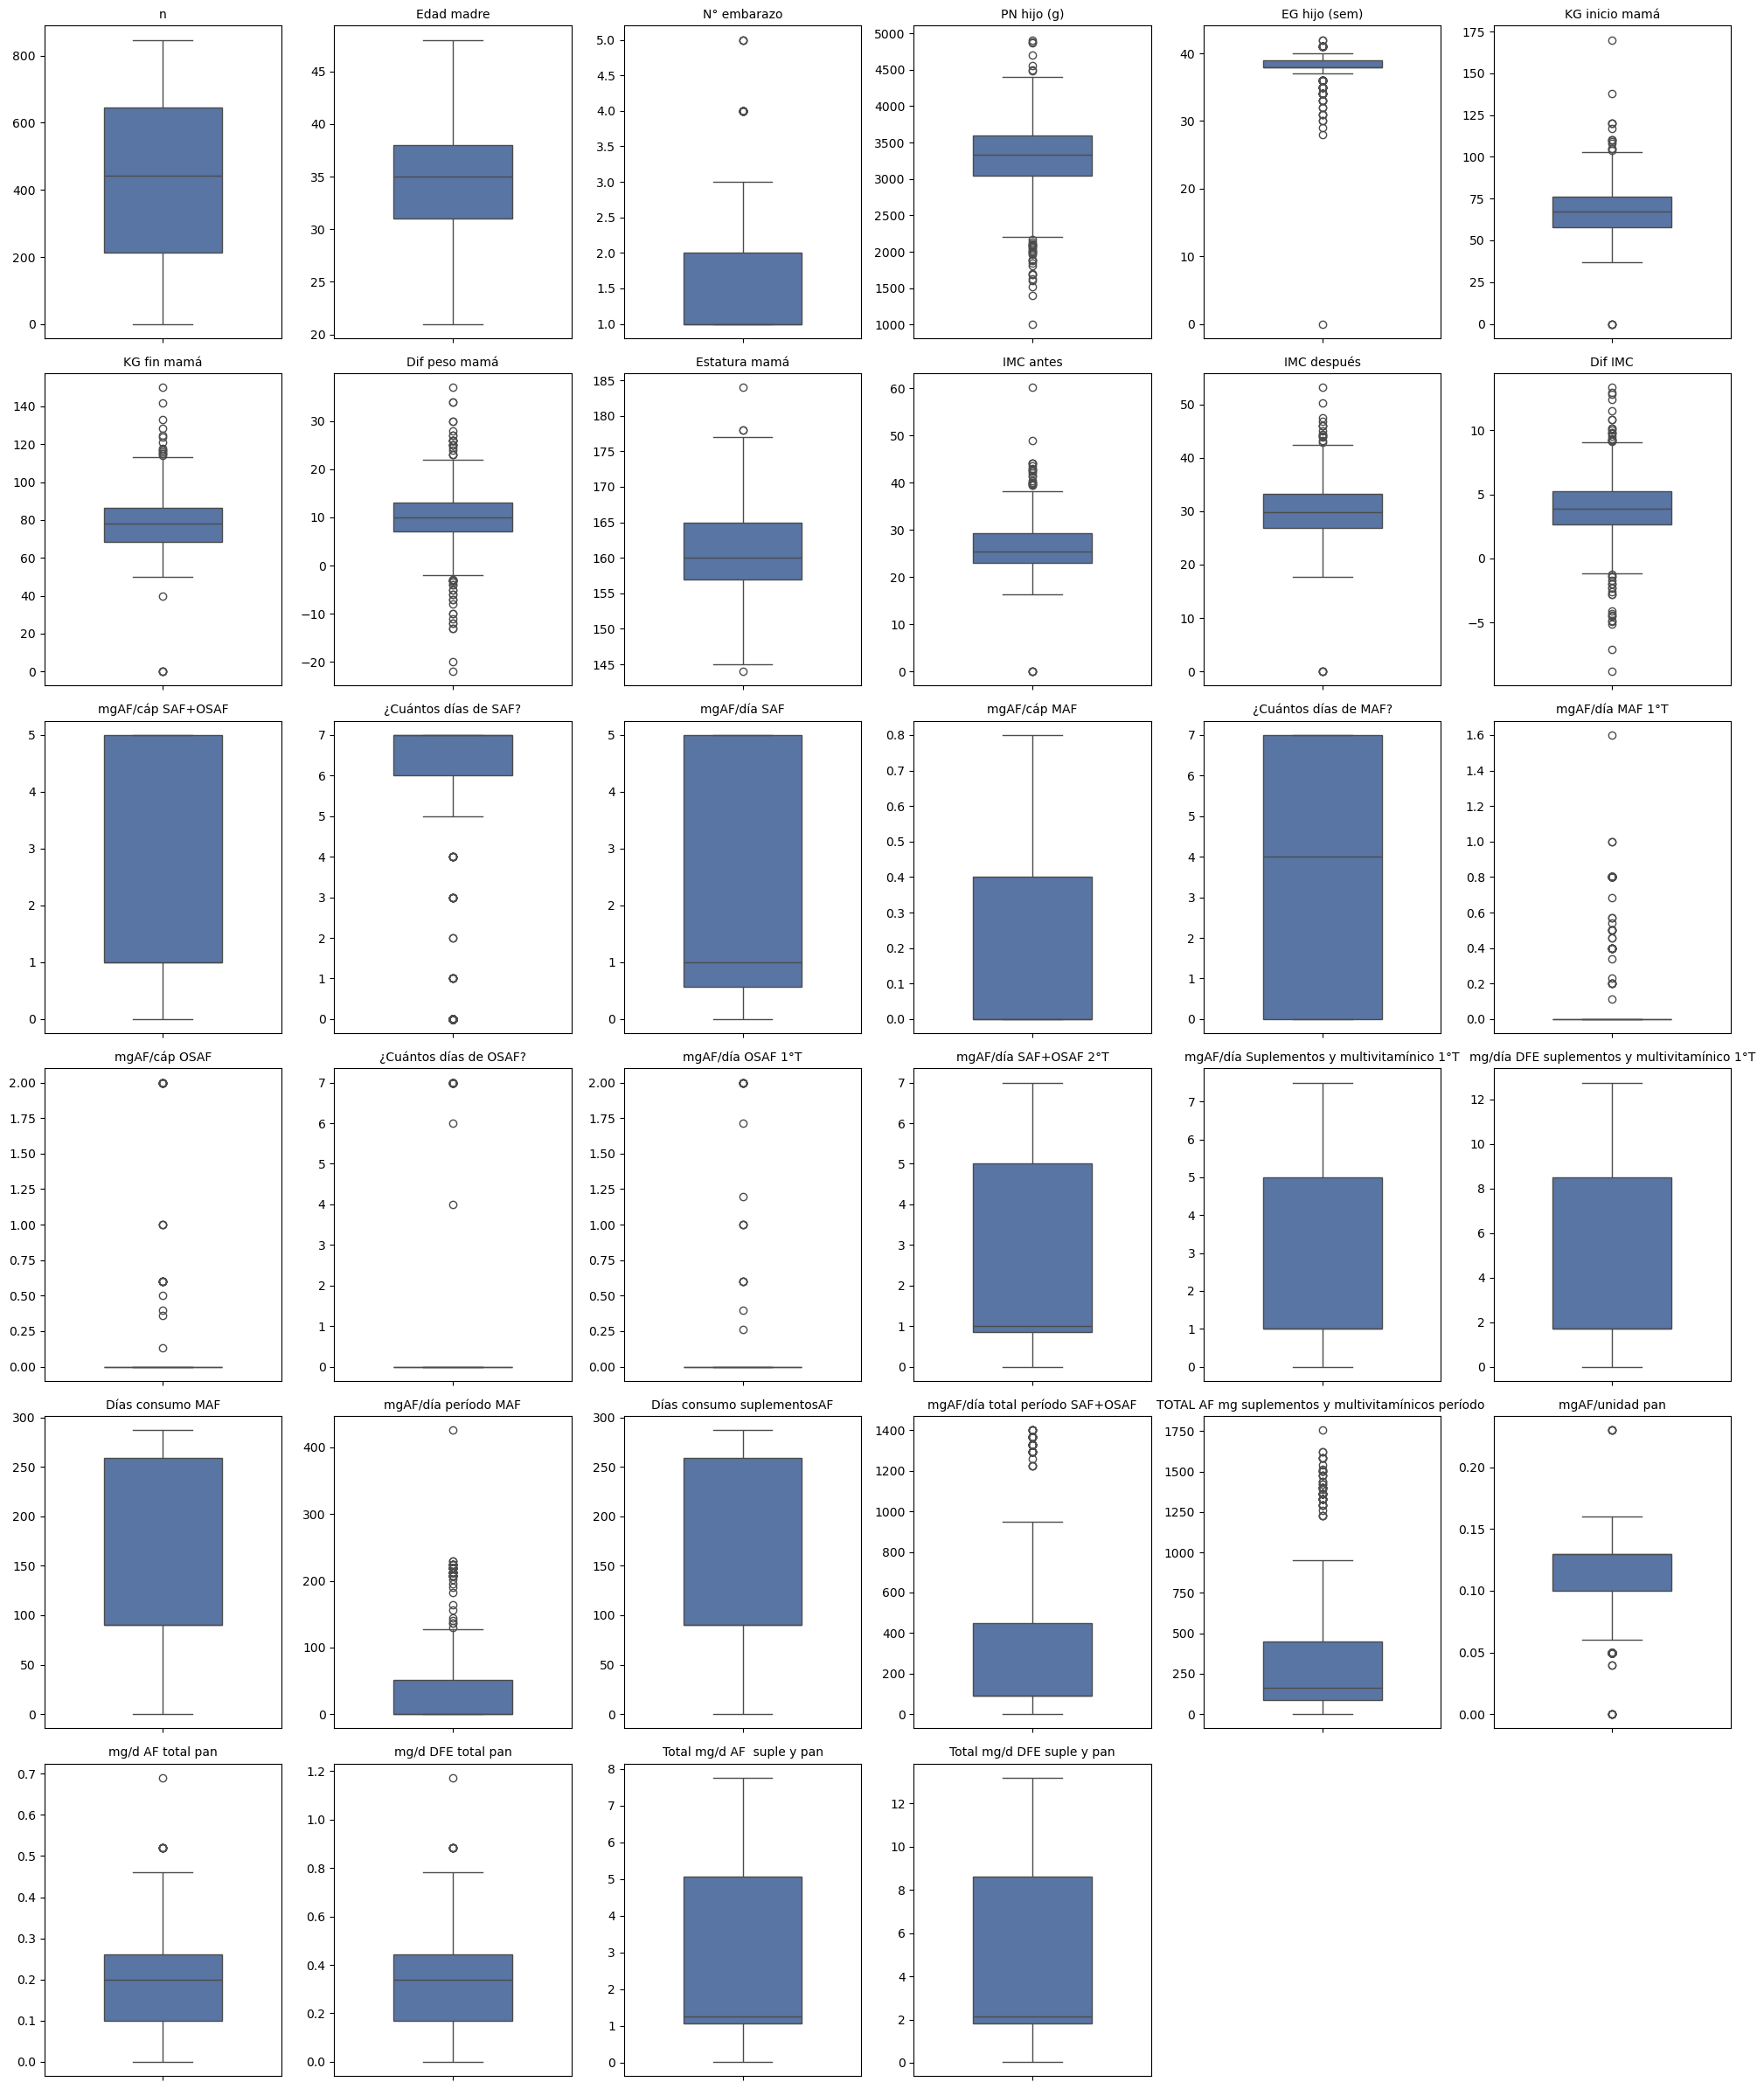

In [13]:
fig, axes = plt.subplots(6, 6, figsize=(20, 24))
axes = axes.flatten()

# Better color choice
color = "#4C72B0"  # soft professional blue

for i, col in enumerate(variables_numericas):
    sns.boxplot(
        data=data_filled,
        y=col,                  # vertical boxplot
        ax=axes[i],
        color=color,
        width=0.5
    )
    
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=0)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2.2 Distribución de Variables Numéricas (Histogramas e Identificación de Valores Atípicos)

In [14]:
# Graficar histogramas de las variables numéricas para ver su distribución
num_cols = len(variables_numericas)
cols = 4
rows = int(np.ceil(num_cols / cols))

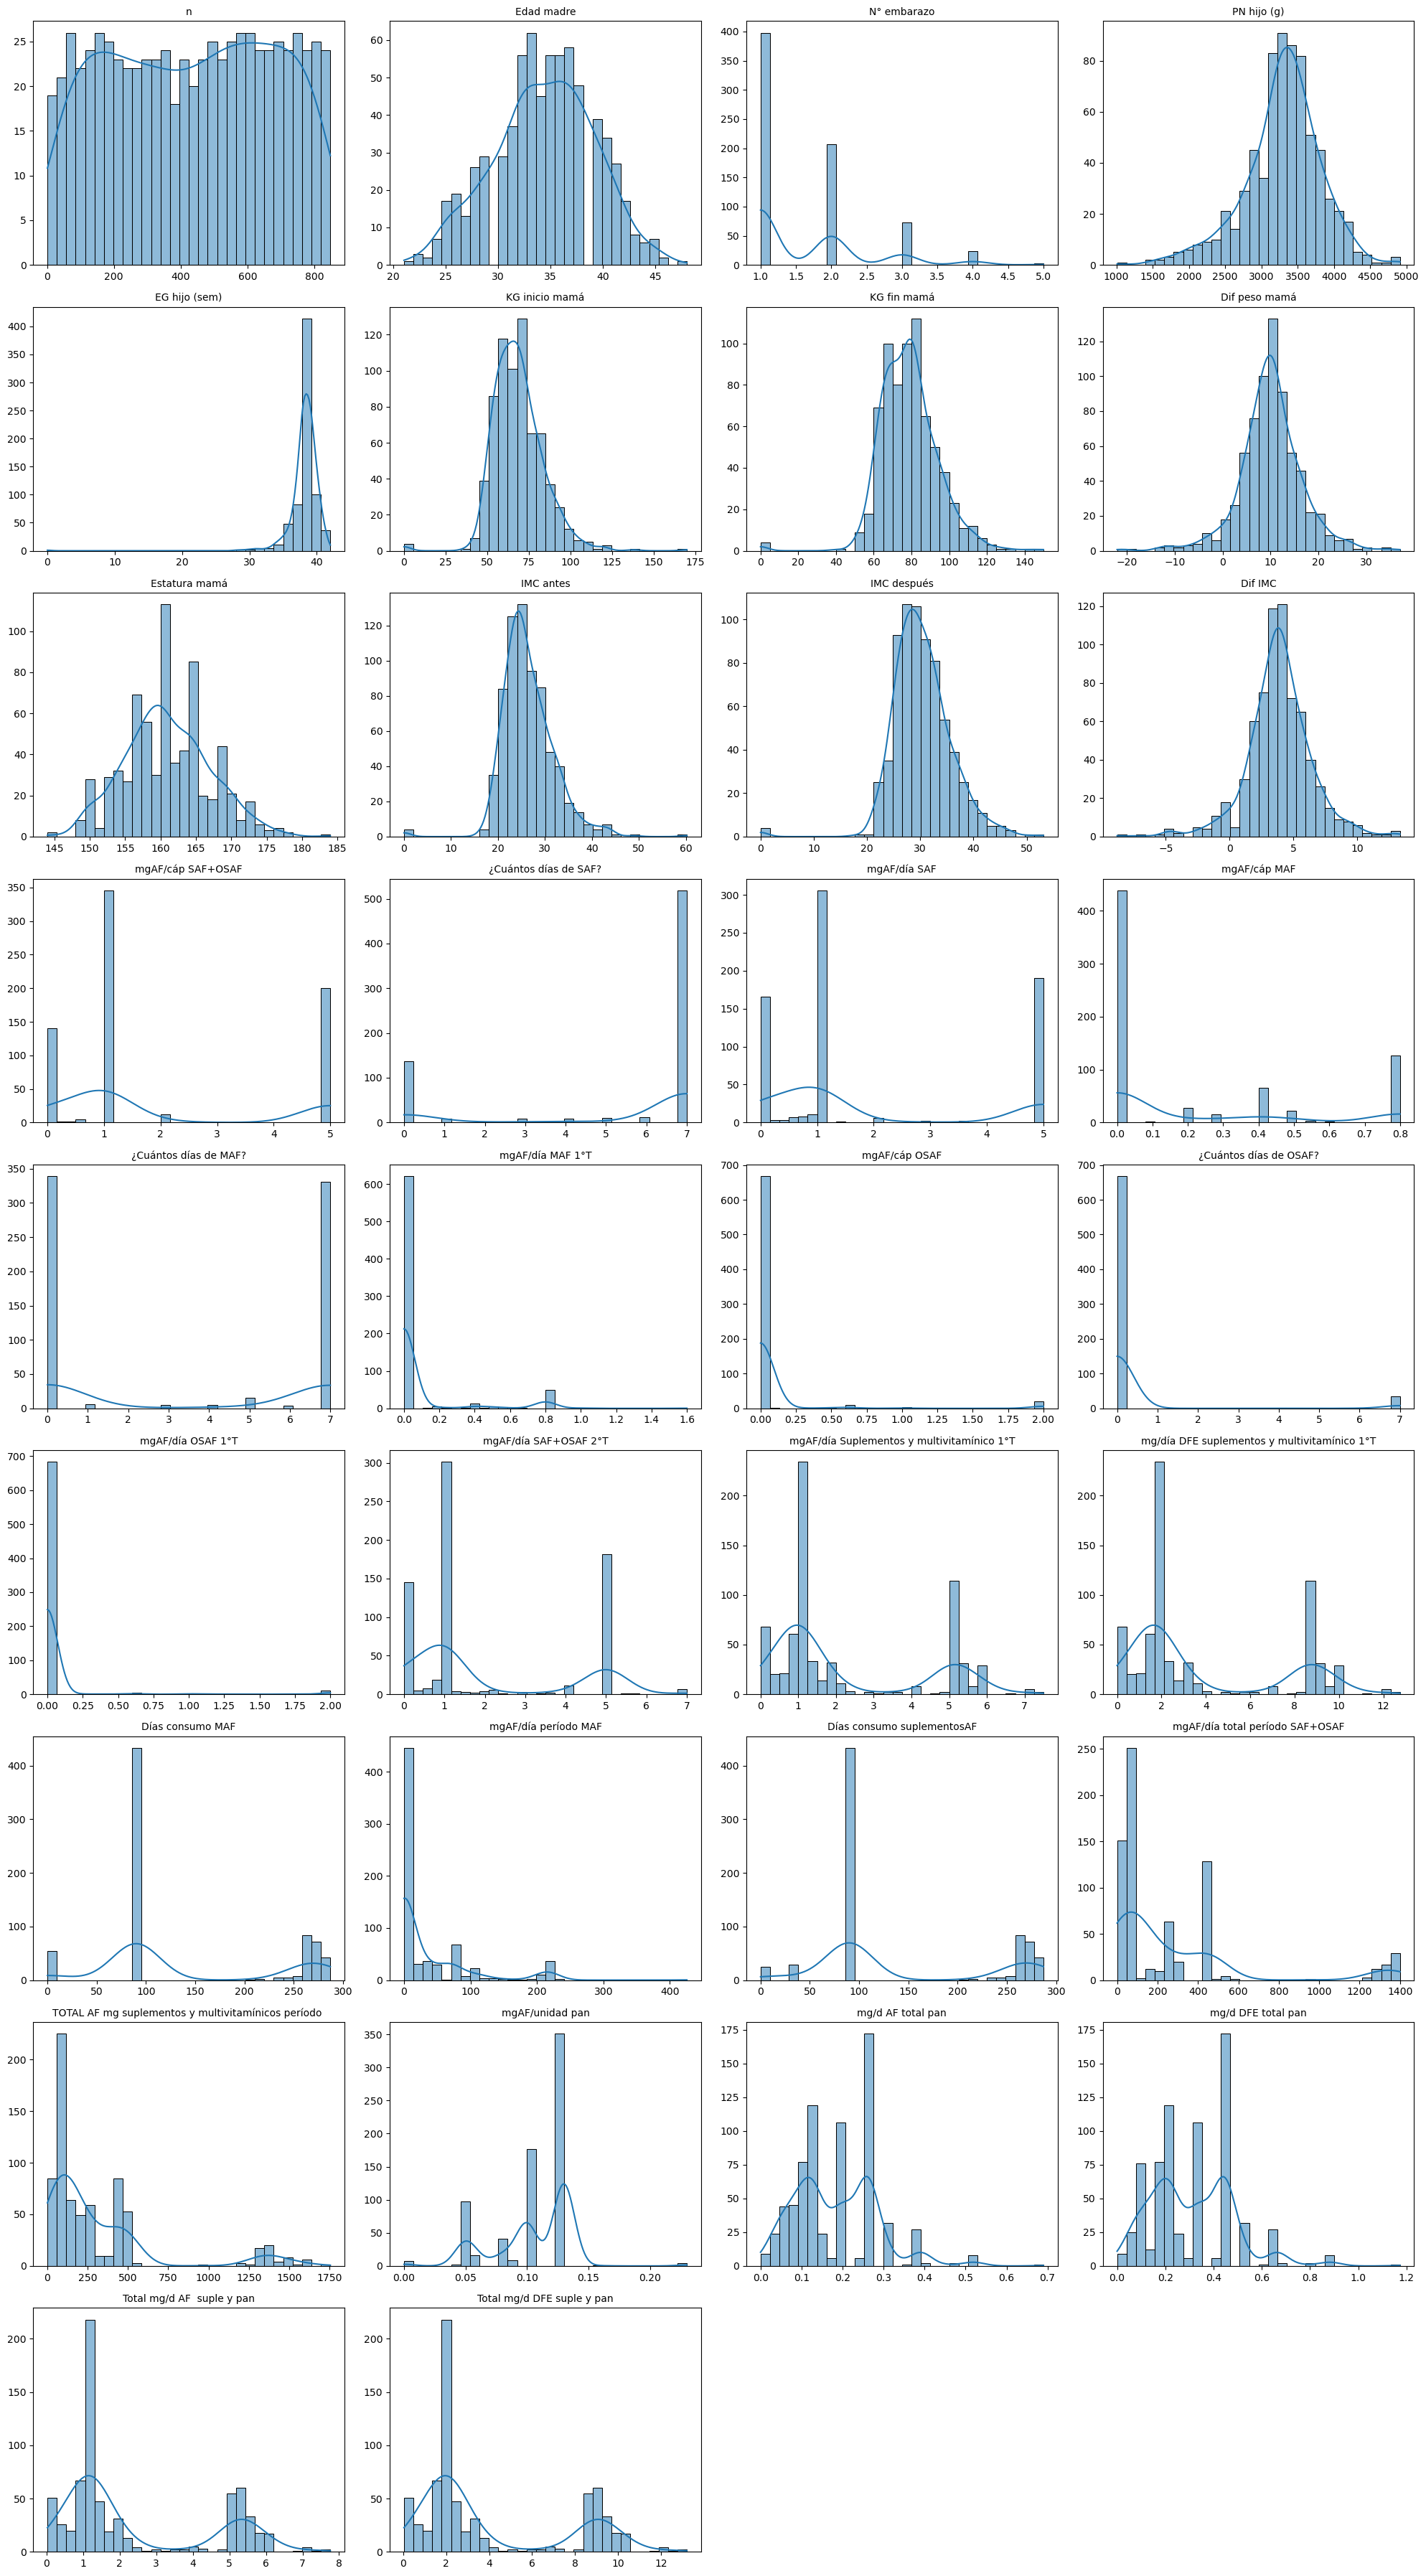

In [15]:
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.histplot(data_filled[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

# Ocultar gráficos vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

### 2.3 Variables Categóricas y Binarias (Frecuencias y distribuciones)

In [16]:
# Graficar la frecuencia para variables binarias y nominales
cat_vars = variables_nominales
num_cat = len(cat_vars)
rows_cat = int(np.ceil(num_cat / cols))

/var/folders/8m/l4ygm3md25s64dm62dskw7_h0000gn/T/ipykernel_4468/1299710525.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_filled[cat_vars], x=col, ax=axes[i], palette='viridis')
/var/folders/8m/l4ygm3md25s64dm62dskw7_h0000gn/T/ipykernel_4468/1299710525.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_filled[cat_vars], x=col, ax=axes[i], palette='viridis')
/var/folders/8m/l4ygm3md25s64dm62dskw7_h0000gn/T/ipykernel_4468/1299710525.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_filled[cat_vars], 

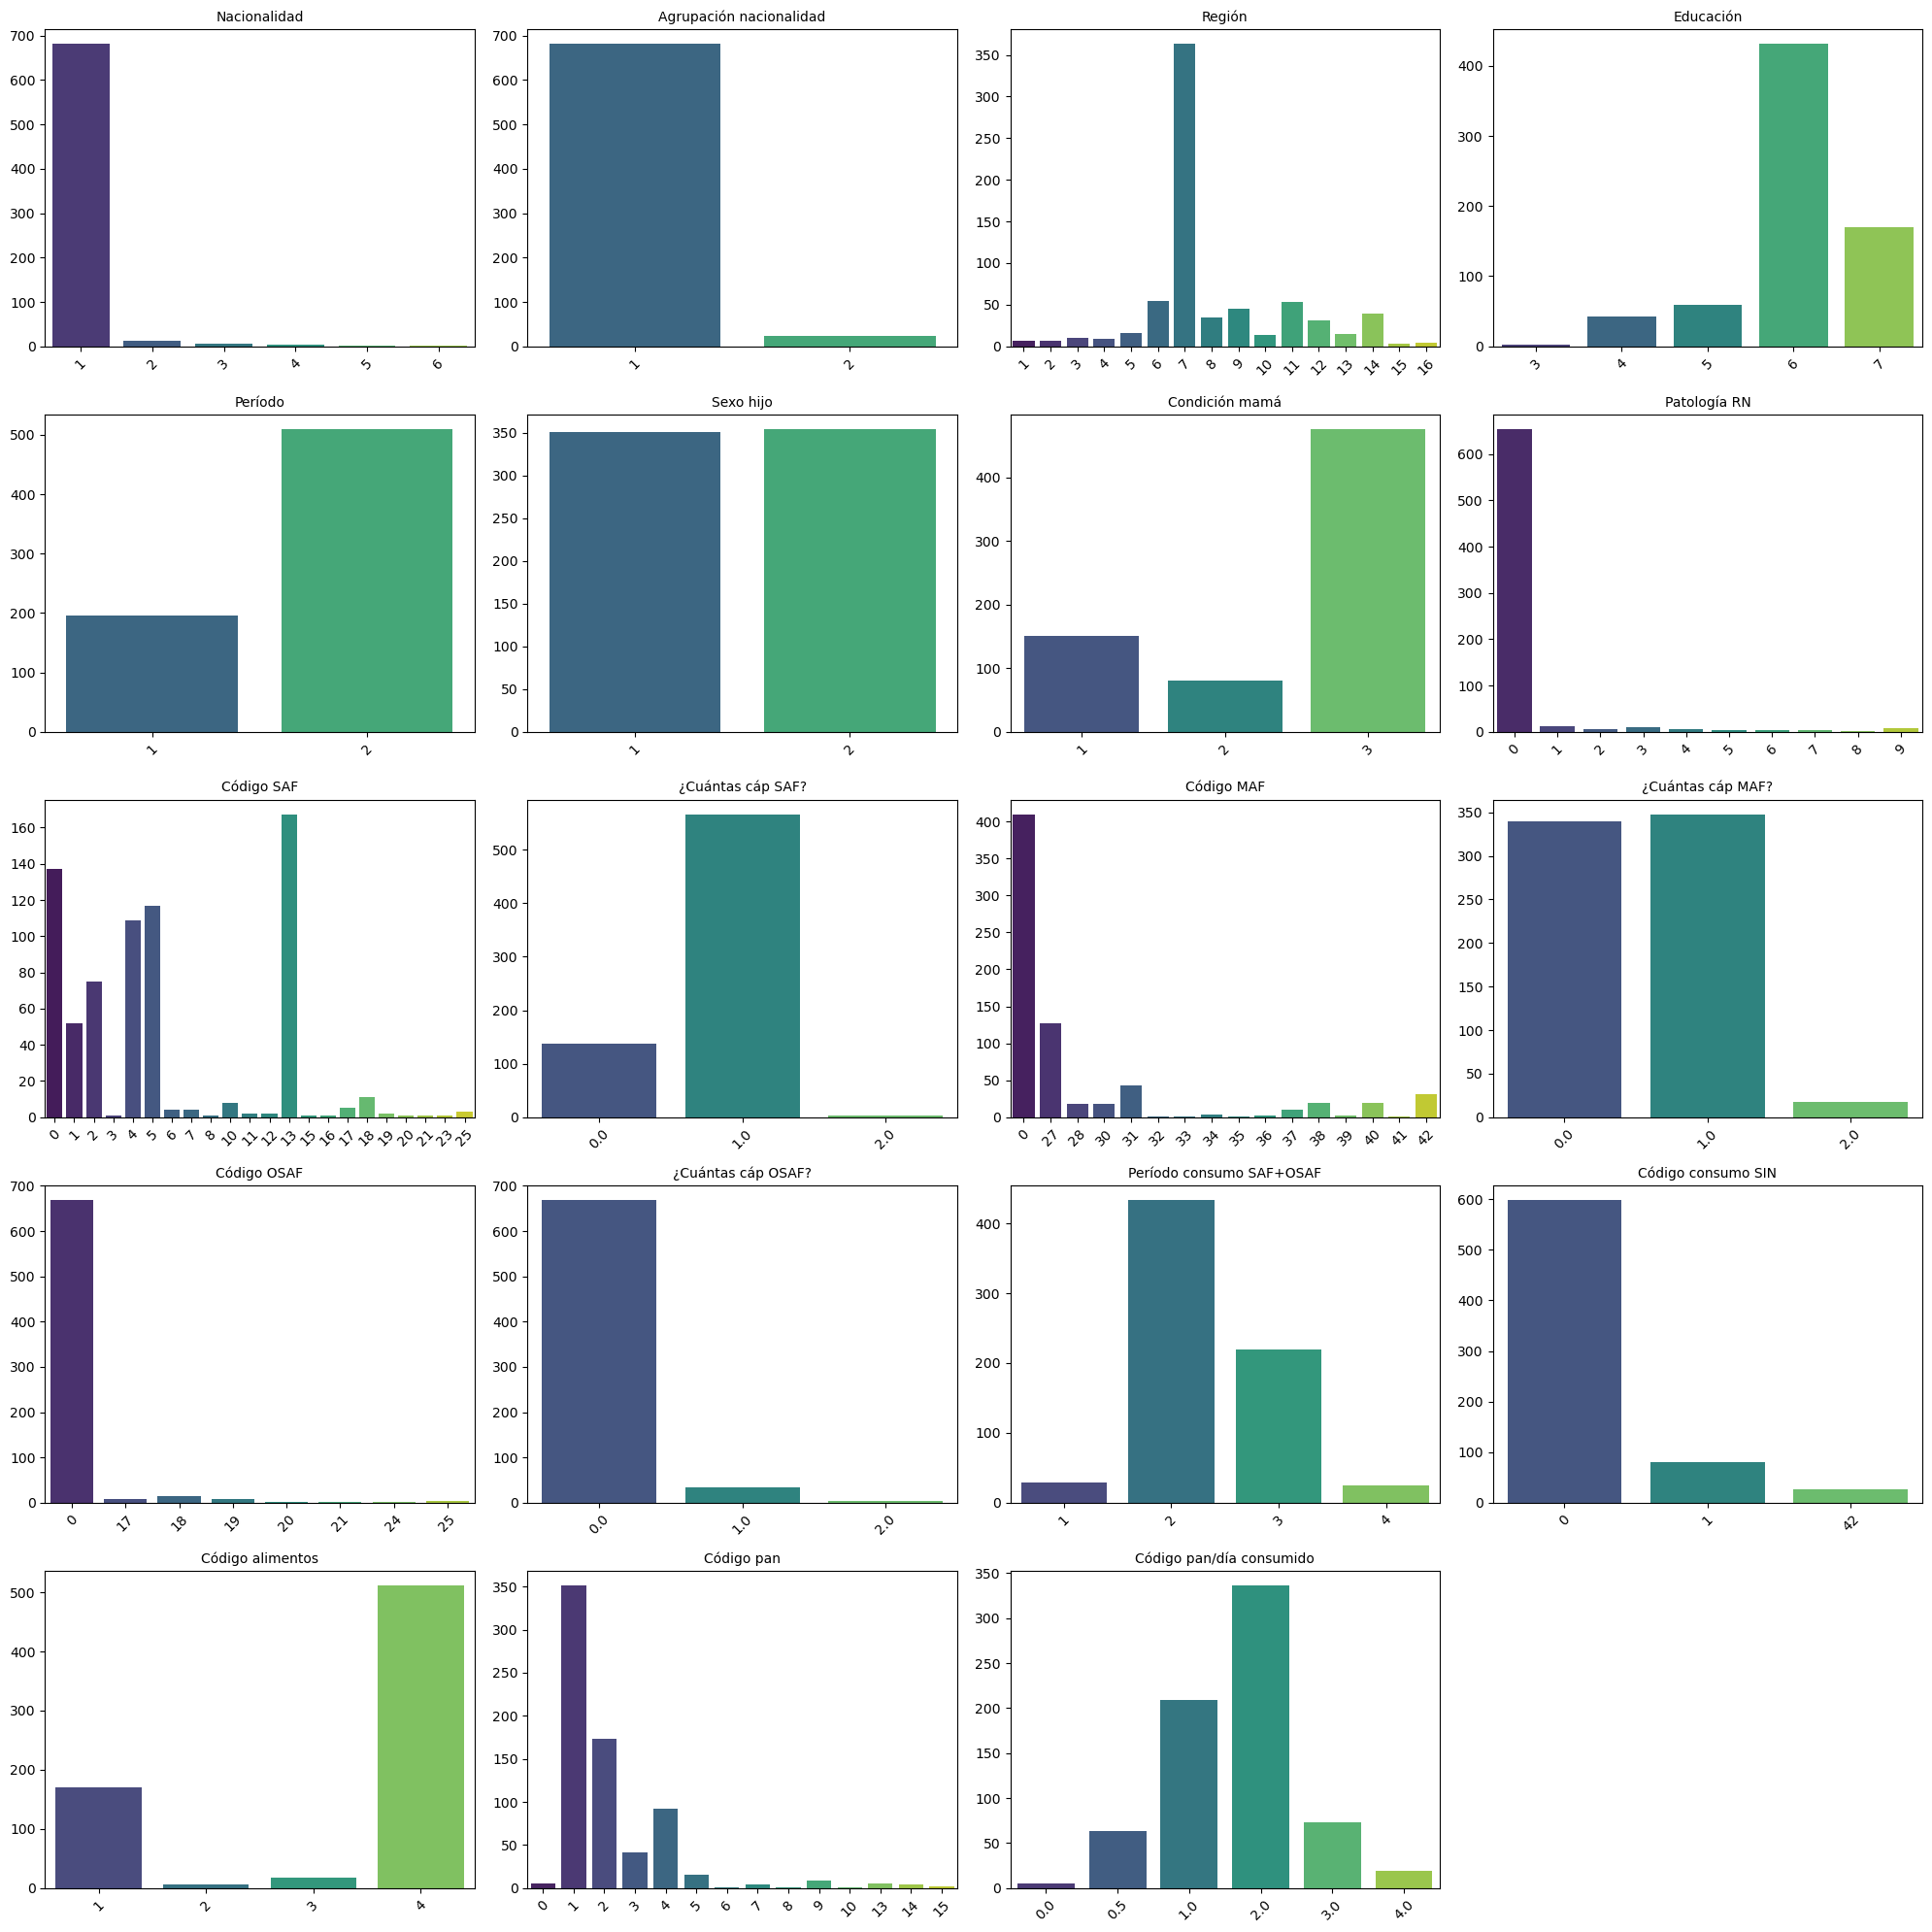

In [17]:
fig, axes = plt.subplots(rows_cat, cols, figsize=(20, 4 * rows_cat))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    sns.countplot(data=data_filled[cat_vars], x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

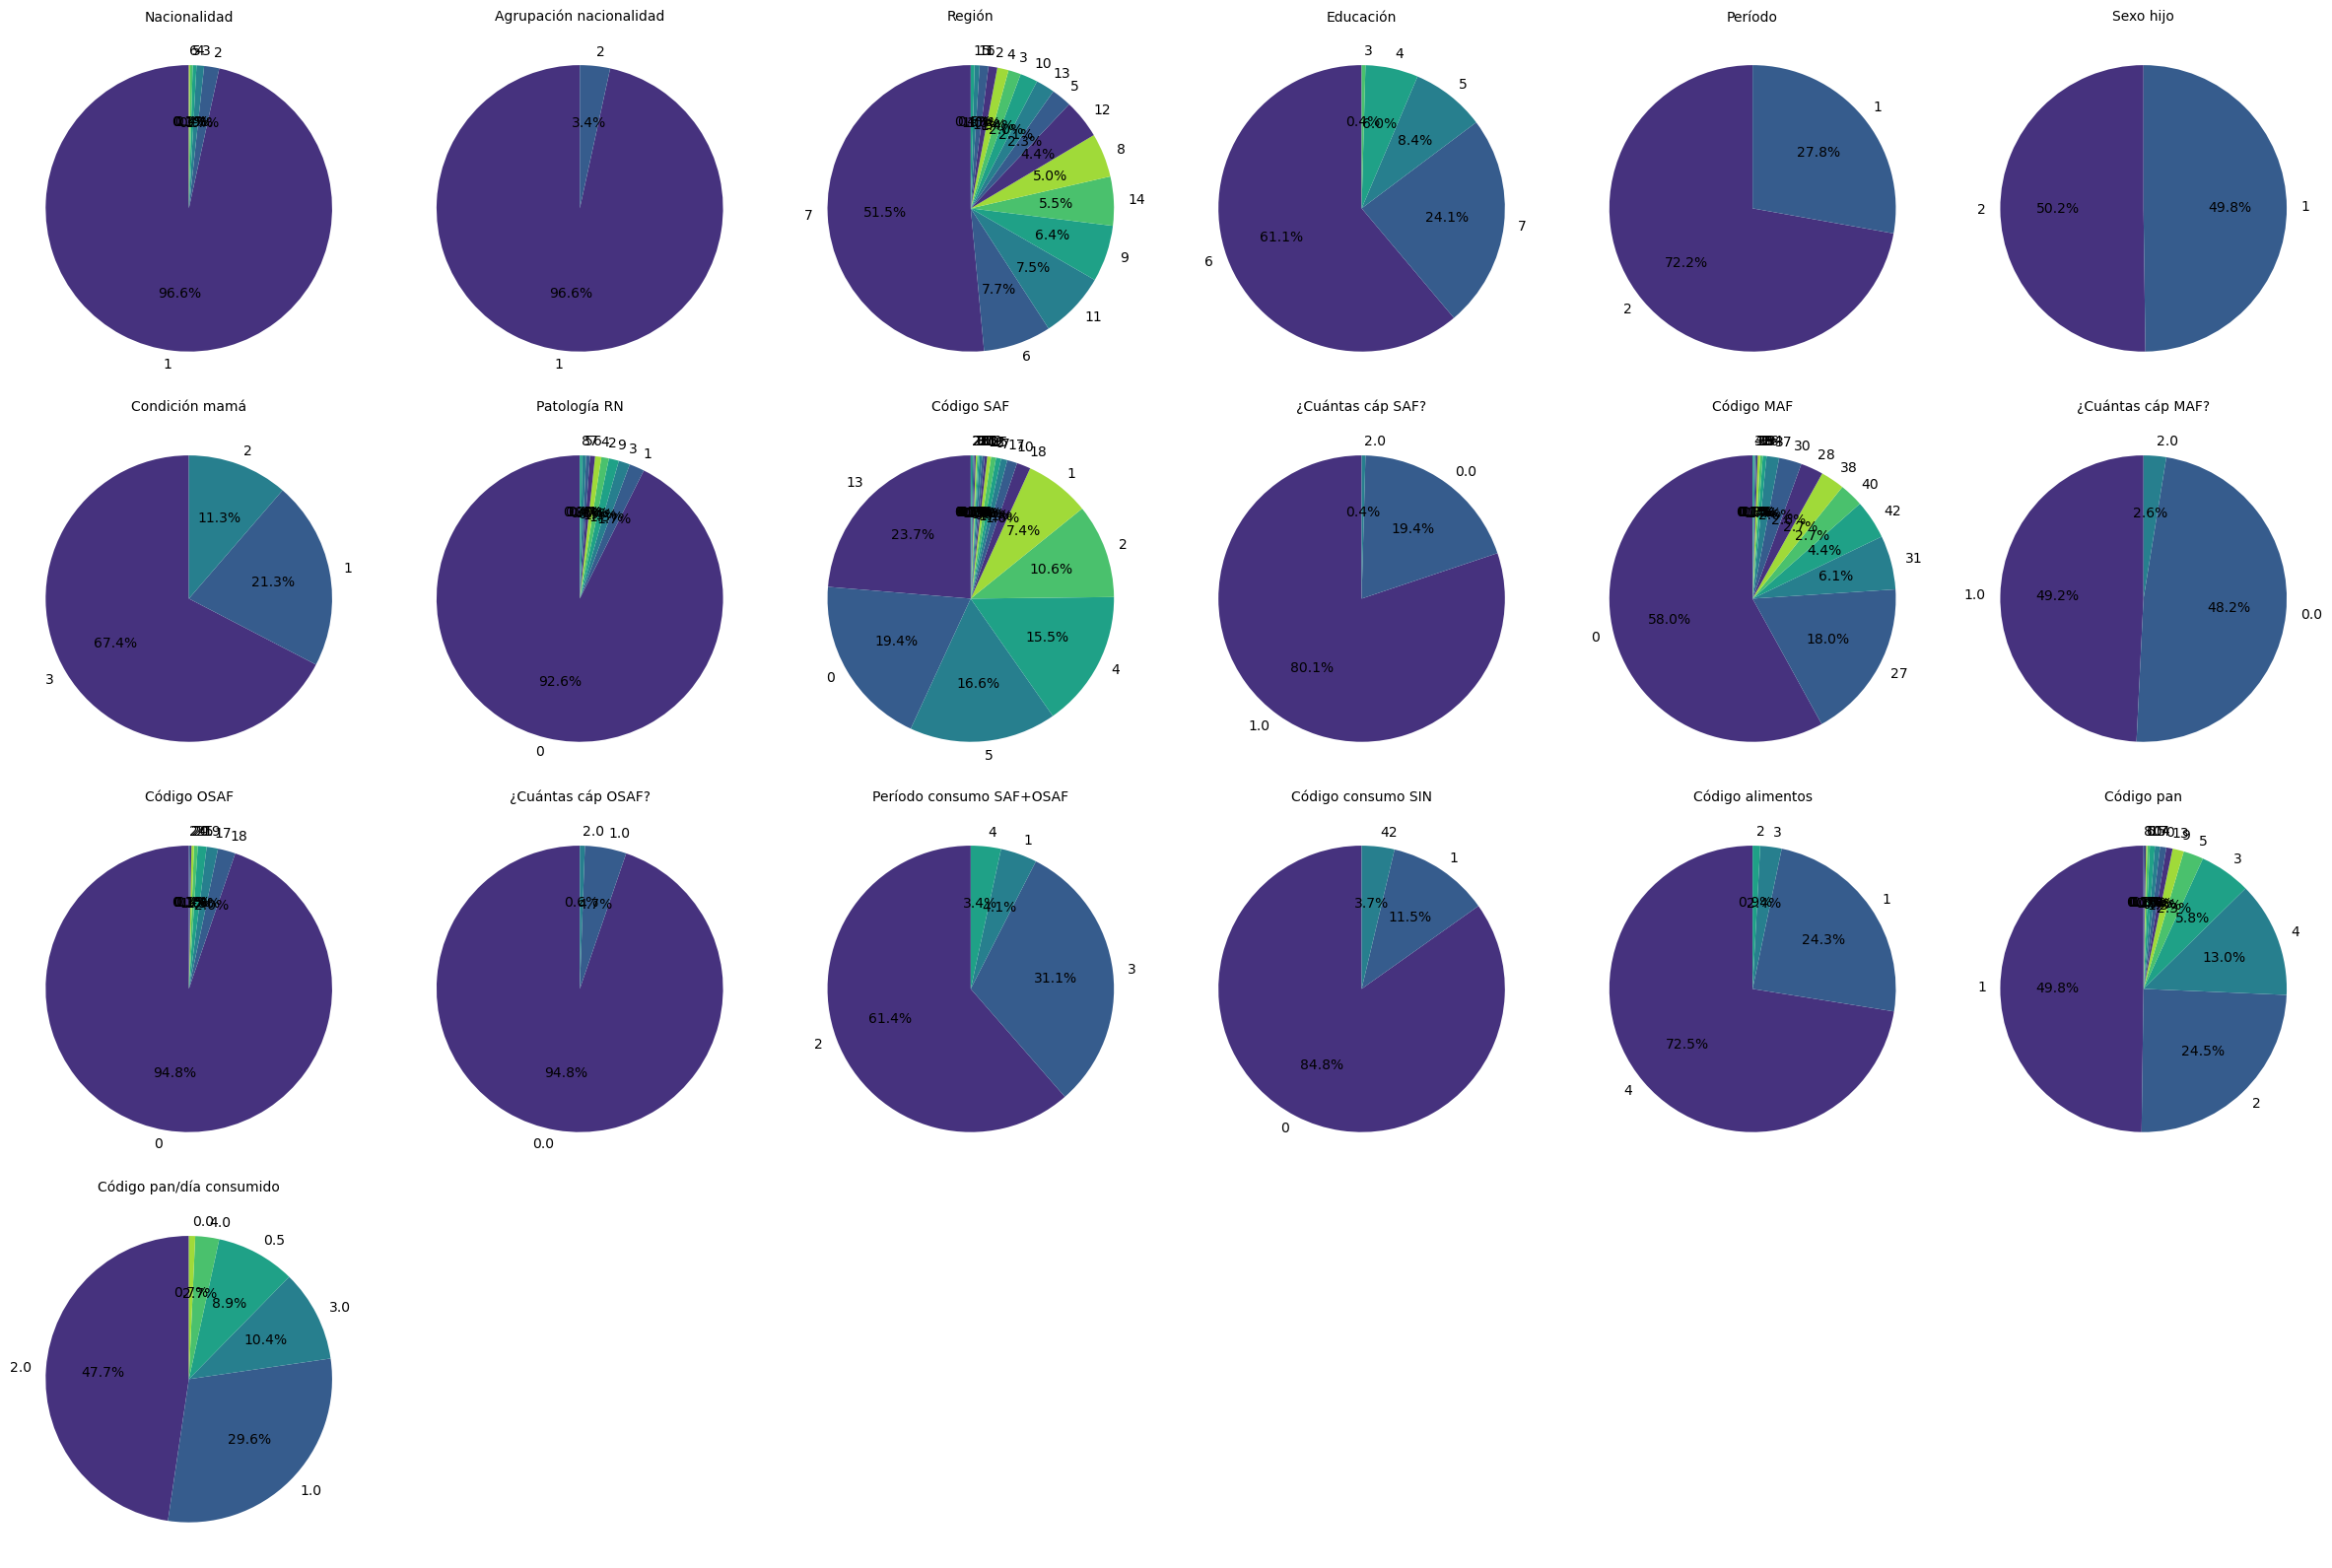

In [18]:
# Distribución de variables categóricas en pie charts
cols = 6  # Número de columnas para los subplots
rows = int(np.ceil(len(cat_vars) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(24, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    data_filled[col].value_counts().plot.pie(
        autopct='%1.1f%%', 
        startangle=90, 
        colors=sns.color_palette('viridis'),
        ax=axes[i]
    )
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_ylabel('')  # Ocultar el label del eje Y

# Ocultar gráficos vacíos si la cantidad de variables no es múltiplo exacto de 'cols'
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2.4 Matriz de Correlación

Calculamos y graficamos las correlaciones (Pearson) entre variables numéricas continuas para identificar posible multicolinealidad.

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create PairGrid
g = sns.PairGrid(
    data_filled[variables_numericas],
    diag_sharey=False,
    height=2.5
)

# Bottom-left: correlation heatmap style (colored scatter by correlation)
def corr_heatmap(x, y, **kws):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    
    # Background color based on correlation
    cmap = plt.cm.coolwarm
    norm = plt.Normalize(-1, 1)
    ax.set_facecolor(cmap(norm(r)))
    
    # Correlation text
    ax.annotate(
        f"{r:.2f}",
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='black'
    )
    
    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])

# Diagonal: histograms
g.map_diag(
    sns.histplot,
    kde=True,
    color="#4C72B0"
)

# Upper-right: scatterplots
g.map_upper(
    sns.scatterplot,
    color="#4C72B0",
    s=15,
    alpha=0.6
)

# Lower-left: correlation heatmap cells
g.map_lower(corr_heatmap)

# Improve layout
g.fig.suptitle(
    'Matriz de Relaciones entre Variables Numéricas',
    fontsize=20,
    y=1.02
)

plt.tight_layout()
plt.show()

### 2.5 Pruebas Estadísticas de Normalidad
Aplicamos la prueba estadística de *Shapiro-Wilk* sobre las variables numéricas para evaluar si siguen una distribución normal empírica. **H0**: La variable proviene de una distribución normal **(Si p-valor < 0.05, se rechaza H0 => No tienen distribución normal).**

In [20]:
from scipy.stats import shapiro
import warnings
warnings.filterwarnings('ignore')

normality_results = []
for col in variables_numericas:
    # Se omiten varianzas constantes o valores que harían fallar Shapiro
    if data_filled[col].nunique() > 1:
        stat, p = shapiro(data_filled[col])
        normal = "Sí" if p > 0.05 else "No"
        normality_results.append({'Variable': col, 'Estadístico': stat, 'p-valor': p, 'Normal': normal})

normality_df = pd.DataFrame(normality_results)
display(normality_df)

,Variable,Estadístico,p-valor,Normal
0,n,0.951312,1.706339e-14,No
1,Edad madre,0.991503,4.479026e-04,No
2,N° embarazo,0.730316,3.167159e-32,No
3,PN hijo (g),0.973363,4.990671e-10,No
4,EG hijo (sem),0.612295,5.957987e-37,No
5,KG inicio mamá,0.930712,1.550775e-17,No
6,KG fin mamá,0.940511,3.498319e-16,No
7,Dif peso mamá,0.956756,1.524488e-13,No
8,Estatura mamá,0.991374,3.925053e-04,No
9,IMC antes,0.920026,7.300410e-19,No


### 3. One-Hot Encoding para Variables Nominales

In [21]:
for col in variables_nominales:
    data_filled[col] = data_filled[col].astype(str)

In [22]:
# Aplicamos One-Hot Encoding
data_ohe = pd.get_dummies(data_filled, columns=variables_nominales, dtype=int)

print(f"Dimensiones del dataset original: {data_filled.shape}")
print(f"Dimensiones del dataset transformado (OHE): {data_ohe.shape}")

# Mostrar las primeras filas y explorar las nuevas columnas
data_ohe.head()

Dimensiones del dataset original: (705, 66)
Dimensiones del dataset transformado (OHE): (705, 179)


,n,Fecha encuesta,Edad madre,FN hijo,N° embarazo,PN hijo (g),EG hijo (sem),KG inicio mamá,KG fin mamá,Dif peso mamá,Estatura mamá,IMC antes,IMC después,Dif IMC,¿Hijo nace c/problema de salud?,¿Consume suplementos y/o multivitamínico de AF en embarazo?,¿Consume SAF?,¿Consume SAF+OSAF?,mgAF/cáp SAF+OSAF,¿Cuántos días de SAF?,mgAF/día SAF,¿Consumió MAF?,¿Consumió MAF completo?,mgAF/cáp MAF,¿Cuántos días de MAF?,mgAF/día MAF 1°T,Consumo OSAF 1° toma,Consumo OSAF 2° toma,Consumo OSAF completo,mgAF/cáp OSAF,¿Cuántos días de OSAF?,mgAF/día OSAF 1°T,mgAF/día SAF+OSAF 2°T,mgAF/día Suplementos y multivitamínico 1°T,mg/día DFE suplementos y multivitamínico 1°T,Días consumo MAF,mgAF/día período MAF,Días consumo suplementosAF,mgAF/día total período SAF+OSAF,TOTAL AF mg suplementos y multivitamínicos período,¿Consumió pan?,mgAF/unidad pan,mg/d AF total pan,mg/d DFE total pan,Total mg/d AF suple y pan,Total mg/d DFE suple y pan,Consumo suple y pan y pastas (si/no),Nacionalidad_1,Nacionalidad_2,Nacionalidad_3,Nacionalidad_4,Nacionalidad_5,Nacionalidad_6,Agrupación nacionalidad_1,Agrupación nacionalidad_2,Región_1,Región_10,Región_11,Región_12,Región_13,Región_14,Región_15,Región_16,Región_2,Región_3,Región_4,Región_5,Región_6,Región_7,Región_8,Región_9,Educación_3,Educación_4,Educación_5,Educación_6,Educación_7,Período_1,Período_2,Sexo hijo_1,Sexo hijo_2,Condición mamá_1,Condición mamá_2,Condición mamá_3,Patología RN_0,Patología RN_1,Patología RN_2,Patología RN_3,Patología RN_4,Patología RN_5,Patología RN_6,Patología RN_7,Patología RN_8,Patología RN_9,Código SAF_0,Código SAF_1,Código SAF_10,Código SAF_11,Código SAF_12,Código SAF_13,Código SAF_15,Código SAF_16,Código SAF_17,Código SAF_18,Código SAF_19,Código SAF_2,Código SAF_20,Código SAF_21,Código SAF_23,Código SAF_25,Código SAF_3,Código SAF_4,Código SAF_5,Código SAF_6,Código SAF_7,Código SAF_8,¿Cuántas cáp SAF?_0.0,¿Cuántas cáp SAF?_1.0,¿Cuántas cáp SAF?_2.0,Código MAF_0,Código MAF_27,Código MAF_28,Código MAF_30,Código MAF_31,Código MAF_32,Código MAF_33,Código MAF_34,Código MAF_35,Código MAF_36,Código MAF_37,Código MAF_38,Código MAF_39,Código MAF_40,Código MAF_41,Código MAF_42,¿Cuántas cáp MAF?_0.0,¿Cuántas cáp MAF?_1.0,¿Cuántas cáp MAF?_2.0,Código OSAF_0,Código OSAF_17,Código OSAF_18,Código OSAF_19,Código OSAF_20,Código OSAF_21,Código OSAF_24,Código OSAF_25,¿Cuántas cáp OSAF?_0.0,¿Cuántas cáp OSAF?_1.0,¿Cuántas cáp OSAF?_2.0,Período consumo SAF+OSAF_1,Período consumo SAF+OSAF_2,Período consumo SAF+OSAF_3,Período consumo SAF+OSAF_4,Código consumo SIN_0,Código consumo SIN_1,Código consumo SIN_42,Código alimentos_1,Código alimentos_2,Código alimentos_3,Código alimentos_4,Código pan_0,Código pan_1,Código pan_10,Código pan_13,Código pan_14,Código pan_15,Código pan_2,Código pan_3,Código pan_4,Código pan_5,Código pan_6,Código pan_7,Código pan_8,Código pan_9,Código pan/día consumido_0.0,Código pan/día consumido_0.5,Código pan/día consumido_1.0,Código pan/día consumido_2.0,Código pan/día consumido_3.0,Código pan/día consumido_4.0
0,1,8/8/2023 20:34:16,36,2/14/22,1,1880,34.0,52.0,65.0,13.0,155.0,21.64,27.06,5.41,0,1,1,1,5.0,7.0,5.000,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,5.000,5.000,8.500,90,0.0,90,450.000,450.000,1,0.13,0.26,0.442,5.260,8.942,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,4,8/9/2023 11:13:30,39,12/27/22,3,3190,38.0,68.0,76.0,8.0,159.0,26.90,30.06,3.16,0,1,0,0,0.0,0.0,0.000,1,1,0.8,7.0,0.8,0,0,0,0.0,0.0,0.0,0.000,0.800,1.360,266,212.8,266,0.000,212.800,1,0.05,0.05,0.085,0.850,1.445,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
2,5,8/9/2023 11:34:11,40,3/2

In [23]:
data_ohe.to_csv('data/dataset2_limpio_ohe.csv')

In [24]:
VARS_SOCIO_D2 = [
    'Edad madre', 'Nacionalidad', 'Agrupación nacionalidad',
    'Región', 'Educación', 'N° embarazo'
]

VARS_ANTROPOMETRIA_D2 = [
    'KG inicio mamá', 'KG fin mamá', 'Dif peso mamá',
    'Estatura mamá', 'IMC antes', 'IMC después', 'Dif IMC'
]

VARS_GESTACION_D2 = [
    'FN hijo', 'Período', 'Sexo hijo',
    'EG hijo (sem)', 'Condición mamá'
]

VARS_AF_SUPL_D2 = [
    '¿Consume suplementos y/o multivitamínico de AF en embarazo?',
    '¿Consume SAF?',
    "¿Consume SAF+OSAF?",
    'Código SAF',
    'mgAF/cáp SAF+OSAF',
    '¿Cuántos días de SAF?',
    '¿Cuántas cáp SAF?',
    'mgAF/día SAF',
    '¿Consumió MAF?',
    "¿Consumió MAF completo?",
    'Código MAF',
    'mgAF/cáp MAF',
    '¿Cuántos días de MAF?',
    '¿Cuántas cáp MAF?',
    'mgAF/día MAF 1°T',
    'Consumo OSAF 1° toma',
    'Consumo OSAF 2° toma',
    'Consumo OSAF completo',
    'Código OSAF',
    'mgAF/cáp OSAF',
    '¿Cuántos días de OSAF?',
    '¿Cuántas cáp OSAF?',
    "mgAF/día OSAF 1°T",
    'mgAF/día SAF+OSAF 2°T',
    'mgAF/día Suplementos y multivitamínico 1°T',
    'mg/día DFE suplementos y multivitamínico 1°T',
    'Días consumo MAF',
    'mgAF/día período MAF',
    'Días consumo suplementosAF',
    'mgAF/día total período SAF+OSAF',
    'TOTAL AF mg suplementos y multivitamínicos período ',
    'Código consumo SIN'
]

VARS_AF_TIMING_D2 = [
    'Período consumo SAF+OSAF',
    'Consumo OSAF 1° toma',
    'Consumo OSAF 2° toma',
    'Consumo OSAF completo'
]

VARS_DIETA_D2 = [
    'Código alimentos',
    '¿Consumió pan?',
    'Código pan',
    'mgAF/unidad pan',
    'Código pan/día consumido',
    'mg/d AF total pan',
    'mg/d DFE total pan',
    'Total mg/d AF  suple y pan',
    'Total mg/d DFE suple y pan',
    'Consumo suple y pan y pastas (si/no)'
]

VARS_OUTCOME_D2 = [
    'PN hijo (g)',
    '¿Hijo nace c/problema de salud?',
    'Patología RN'
]